# Dependencies

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn


In [26]:
# pandas and NumPy
import pandas as pd
import numpy as np

# Seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression 
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import svm


# K-Means clustering
from sklearn.cluster import KMeans

# Train / test split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn import metrics


# 1. Data pre-processing


In [29]:
df = pd.read_csv('laptops_data.csv')

df.head()

,Unnamed: 0,Name,Discounted Price,Actual Price,Saving,Rating,Reviews,Brand,Core,SSD,Model
0,0,Apple MacBook Air 13 M1 MGN63 (8GB-256GB),203499.0,258000.0,21% OFF,5.0,2.0,Apple,M1,NaN,MacBook Air 13 M1 MGN63
1,1,Apple Macbook Air 13 MW123 M4 Chip,281999.0,350000.0,19% OFF,4.3,5.0,Apple,M4,NaN,Macbook Air 13 MW123 M4 Chip
2,2,ASUS Zenbook 14 UX3405CA Intel Core Ultra 7 25...,285999.0,330000.0,13% OFF,NaN,NaN,ASUS,Ultra 7,16GB-512GB SSD,Zenbook 14 UX3405CA Intel Core Ultra 7 255H
3,3,Lenovo ThinkPad E16 Gen 2 - Intel Core Ultra 7...,287999.0,340000.0,15% OFF,NaN,NaN,Lenovo,Ultra 7,NaN,ThinkPad E16 Gen 2 - Intel Core Ultra 7
4,4,Lenovo IdeaPad Slim 3 Ryzen 7 (8GB-512GB),146999.0,175000.0,16% OFF,NaN,NaN,Lenovo,Ryzen 7,NaN,IdeaPad Slim 3 Ryzen 7


In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        306 non-null    int64  
 1   Name              306 non-null    object 
 2   Discounted Price  306 non-null    float64
 3   Actual Price      291 non-null    float64
 4   Saving            291 non-null    object 
 5   Rating            26 non-null     float64
 6   Reviews           26 non-null     float64
 7   Brand             306 non-null    object 
 8   Core              219 non-null    object 
 9   SSD               92 non-null     object 
 10  Model             306 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 26.4+ KB
None


In [31]:
df.isnull().mean() * 100


Unnamed: 0           0.000000
Name                 0.000000
Discounted Price     0.000000
Actual Price         4.901961
Saving               4.901961
Rating              91.503268
Reviews             91.503268
Brand                0.000000
Core                28.431373
SSD                 69.934641
Model                0.000000
dtype: float64

- Rating and Reviews contain a high proportion of missing values and cannot be reliably imputed, so these columns are removed.

- The first column is unnamed and corresponds to an automatically generated CSV index, so it is dropped.

- The Name column contains multiple technical specifications in a single string. Since the Model column already stores the model name, we extract RAM and storage capacity from Name into two new columns (RAM_GB and Storage_GB).

- The SSD column is inconsistent: many laptops that clearly contain SSD storage do not have this information filled. Therefore, storage information is systematically extracted from Name, and the SSD column is removed.

- After feature extraction, the Name column becomes redundant and is therefore removed.

In [32]:
df1 = df.iloc[:, 1:].copy()

# RAM and storage extraction 

# the specs are in parantheses, so we start by extracting what's inside them
# Extract only parentheses containing GB (RAM + Storage), because some name models have parentheses like Infinix INBOOK Air (XL442) Core i3 1215U (8GB - 256GB)
specs = df1['Name'].str.extract(r'\(([^)]*GB[^)]*)\)', expand=False)

# Split on first GB
split_specs = specs.str.split(r'GB', n=1, expand=True)

# RAM (left part)
df1['RAM_GB'] = split_specs[0].str.extract(r'(\d+)').astype(float)

# Storage (right part)
storage = split_specs[1].str.extract(r'(\d+)\s*(TB|GB)', expand=True)

df1['Storage_GB'] = np.where(
    storage[1] == 'TB',
    storage[0].astype(float) * 1024,
    storage[0].astype(float)
)

# Saving extraction (%)
df1['Saving_percent'] = (
    df1['Saving']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Drop useless columns
df1 = df1.drop(columns=['Name','Rating', 'Reviews', 'SSD', 'Saving'])

df1.head(10)


,Discounted Price,Actual Price,Brand,Core,Model,RAM_GB,Storage_GB,Saving_percent
0,203499.0,258000.0,Apple,M1,MacBook Air 13 M1 MGN63,8.0,256.0,21.0
1,281999.0,350000.0,Apple,M4,Macbook Air 13 MW123 M4 Chip,NaN,NaN,19.0
2,285999.0,330000.0,ASUS,Ultra 7,Zenbook 14 UX3405CA Intel Core Ultra 7 255H,16.0,512.0,13.0
3,287999.0,340000.0,Lenovo,Ultra 7,ThinkPad E16 Gen 2 - Intel Core Ultra 7,16.0,512.0,15.0
4,146999.0,175000.0,Lenovo,Ryzen 7,IdeaPad Slim 3 Ryzen 7,8.0,512.0,16.0
5,115999.0,144999.0,HP,NaN,250 G10 Ci3 N305,8.0,512.0,20.0
6,169999.0,249999.0,Dell,NaN,Latitude 3540 Ci5-1335U 15.6 FHD,8.0,256.0,32.0
7,343999.0,415000.0,Dell,Core i7,Latitude 15 5540 15.6 Inches 13th Gen Core i7 DOS,8.0,512.0,17.0
8,251999.0,320000.0,Dell,Core i7,Latitude 15 3540 15.6 Inches 13th Gen Core i7 DOS,8.0,512.0,21.0
9,134999.0,174999.0,Lenovo,Core i5,IdeaPad Slim 3 Core i5 13th Gen,NaN,NaN,23.0


In [33]:
df1.isnull().mean()*100

Discounted Price     0.000000
Actual Price         4.901961
Brand                0.000000
Core                28.431373
Model                0.000000
RAM_GB              20.261438
Storage_GB          20.588235
Saving_percent       4.901961
dtype: float64

In [34]:
df1.duplicated().sum()

np.int64(0)

# 2. Exploratory data analysis

## 2.1 Quantitative variables

In [35]:
# Extracting quanitaive features
df_qnt = df1.select_dtypes(include=['float64', 'int64'])
df_qnt.head()

,Discounted Price,Actual Price,RAM_GB,Storage_GB,Saving_percent
0,203499.0,258000.0,8.0,256.0,21.0
1,281999.0,350000.0,NaN,NaN,19.0
2,285999.0,330000.0,16.0,512.0,13.0
3,287999.0,340000.0,16.0,512.0,15.0
4,146999.0,175000.0,8.0,512.0,16.0


In [36]:
df_qnt.describe()

,Discounted Price,Actual Price,RAM_GB,Storage_GB,Saving_percent
count,3.060000e+02,2.910000e+02,244.000000,243.000000,291.000000
mean,2.775879e+05,3.212616e+05,14.508197,641.580247,14.587629
std,1.708020e+05,1.802598e+05,9.388063,320.260439,8.008727
min,8.599900e+04,1.119990e+05,4.000000,256.000000,2.000000
25%,1.742490e+05,2.000000e+05,8.000000,512.000000,8.000000
50%,2.344990e+05,2.800000e+05,16.000000,512.000000,14.000000
75%,3.449998e+05,3.800000e+05,16.000000,512.000000,20.000000
max,1.552999e+06,1.599900e+06,64.000000,2048.000000,45.000000


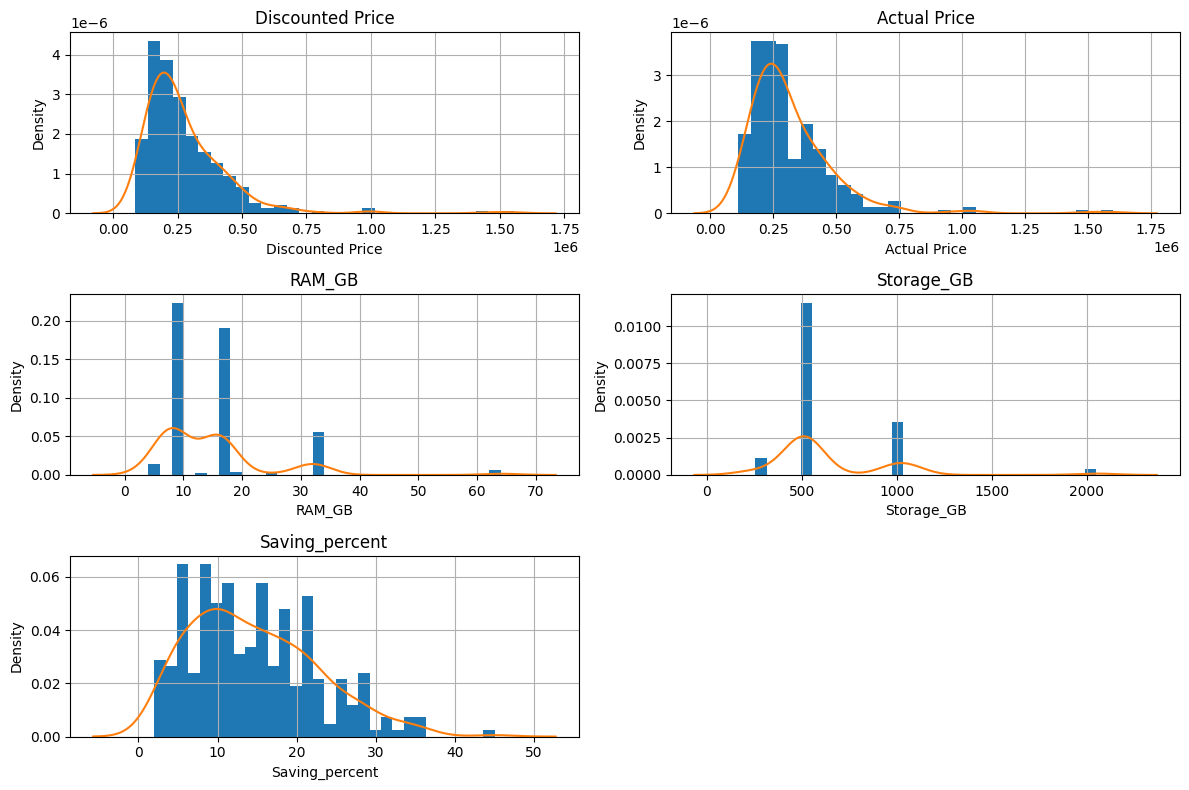

In [37]:
df_qnt.hist(
    bins=30,
    figsize=(12,8),
    density=True
)

for ax in plt.gcf().axes:
    for col in df_qnt.columns:
        if ax.get_title() == col:
            sns.kdeplot(df_qnt[col], ax=ax)

plt.tight_layout()
plt.show()


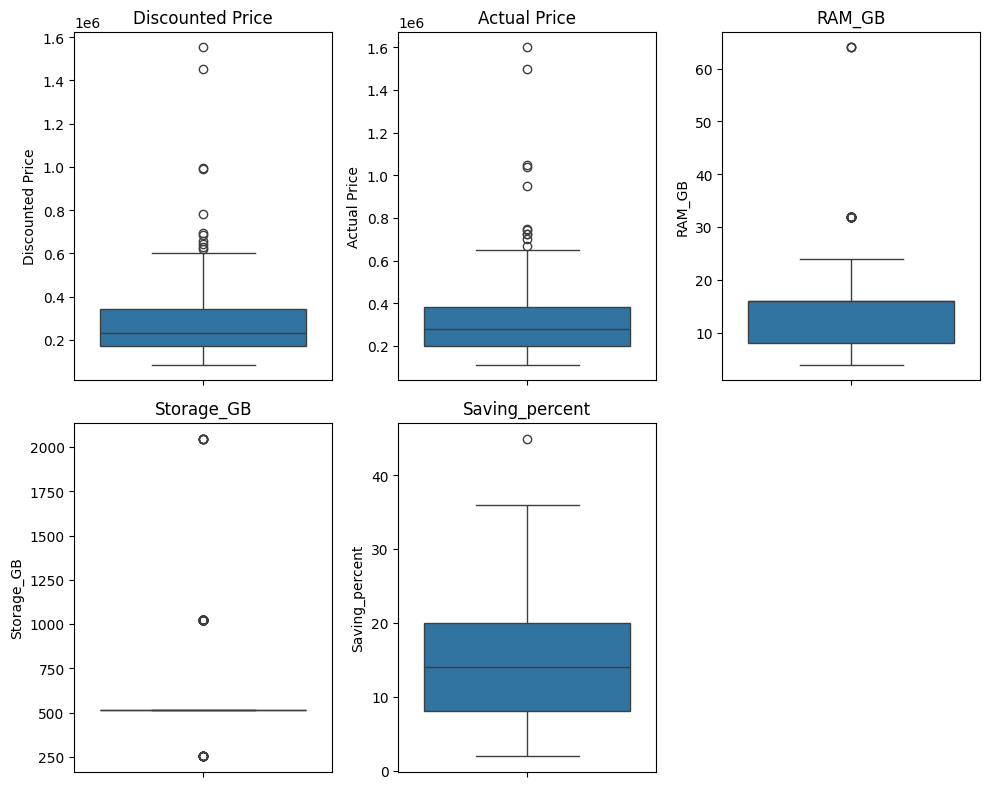

In [38]:
cols = df_qnt.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(10, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_qnt[col])
    plt.title(col)

plt.tight_layout()
plt.show()


The variables do not follow a normal distribution. Most distributions are right-skewed, with a concentration of values at lower ranges and a few extreme high values acting as outliers, especially for the price.

## 2.2 Qualitative variables 

In [39]:
df_cat = df1[['Brand', 'Core']]
df_cat.head()


,Brand,Core
0,Apple,M1
1,Apple,M4
2,ASUS,Ultra 7
3,Lenovo,Ultra 7
4,Lenovo,Ryzen 7


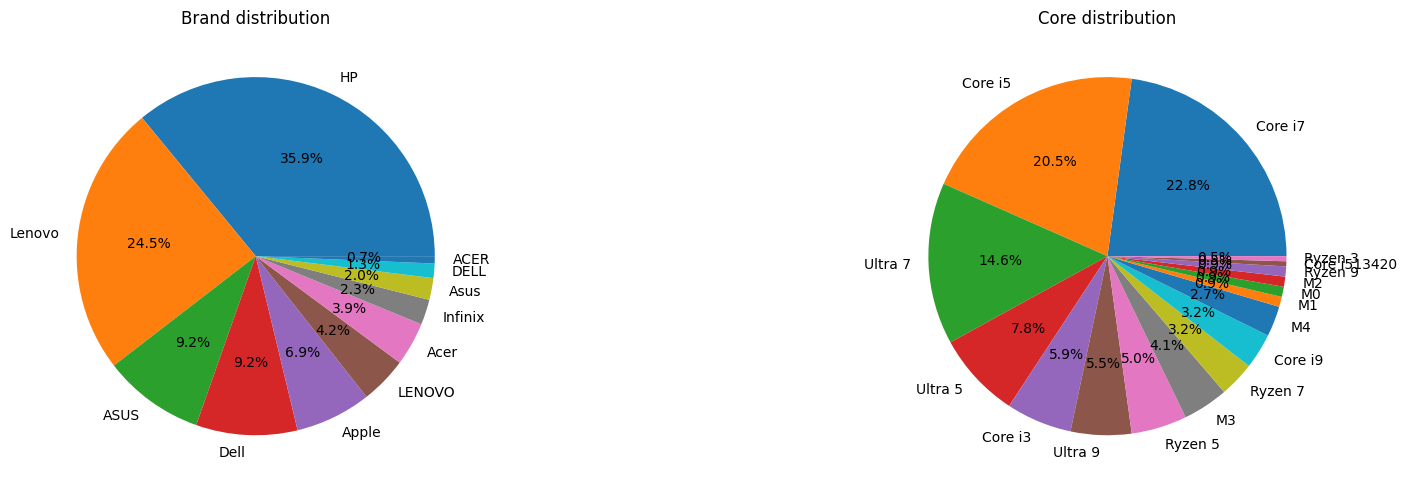

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Brand
df1['Brand'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0]
)
axes[0].set_title('Brand distribution')
axes[0].set_ylabel('')

# Core
df1['Core'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1]
)
axes[1].set_title('Core distribution')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()


The brand distribution is dominated by a few major manufacturers, with HP and Lenovo representing a large share of the dataset, while many other brands appear marginally.

Processor types are mainly concentrated around Intel Core i5 and i7, indicating a focus on mid- to high-range laptops.

## 2.3 Multivariate analysis

* Normalization

In [41]:
scaler = StandardScaler()
df_qnt_scaled = pd.DataFrame(
    scaler.fit_transform(df_qnt),
    columns=df_qnt.columns
)

df_qnt_scaled.head()

,Discounted Price,Actual Price,RAM_GB,Storage_GB,Saving_percent
0,-0.434481,-0.351551,-0.694667,-1.206443,0.802052
1,0.025868,0.159702,NaN,NaN,0.551894
2,0.049325,0.048560,0.159231,-0.405444,-0.198579
3,0.061054,0.104131,0.159231,-0.405444,0.051579
4,-0.765815,-0.812791,-0.694667,-0.405444,0.176658


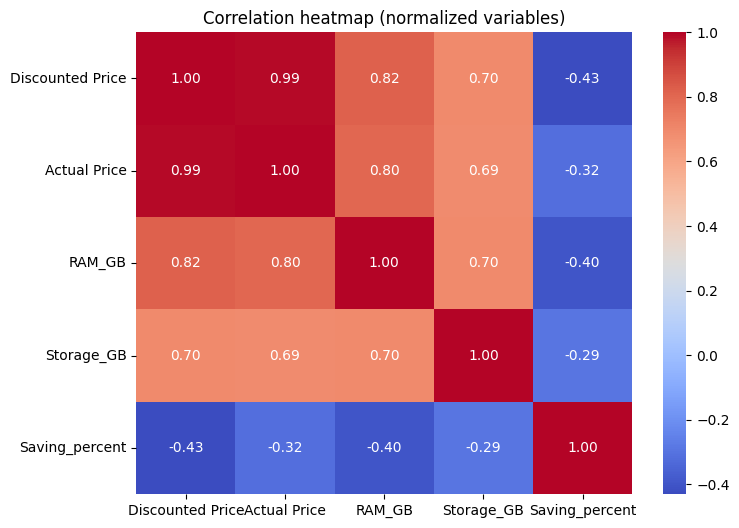

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_qnt_scaled.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation heatmap (normalized variables)')
plt.show()


- Strong relationship between discounted and actual prices, which is expected and intuitive.

- The correlation between actual price and saving percentage is low and negative, meaning that higher-priced laptops tend to have lower relative discounts, although the relationship remains weak.

- RAM and storage are positively correlated with price, indicating that higher hardware specifications generally correspond to higher prices.

# 3. Unsupervised Learning – K-Means Clustering
